# RA5 — Choice-history-conditioned switching, and a signed-deviation feature ablation

**Reviewer comment IDs: R1-f, R2-3.**

Two independent sub-analyses, each tied to its own figure's own data
source (neither figure itself is modified):

**Part 1 (R1-f)**: extends Fig 2e's history analysis. Fig 2e itself
conditions P(switch) on the trailing reward sequence alone
(`switch_by_history.switch_probability_by_history`, unchanged) — this
part additionally conditions jointly on the trailing CHOICE sequence, on
the exact same data Fig 2 itself uses
(`fig2.input_files.reversal_100_0`), to check whether choice identity
adds anything beyond outcome history.

**Part 2 (R2-3)**: extends Fig 6 / Supp Fig 4's K-Means/HMM validation.
Uses the same canonical 80-20 2-ABT snapshot, `classify_state_v3` target,
and single session train/test split Fig 6 itself uses
(`state_clustering.train_test_split_sessions`) — not RA2's k-fold CV,
since this is a feature-ablation question, not a re-estimate of ARI's own
uncertainty. Compares K-Means/HMM recovery WITH vs. WITHOUT
`Signed_Deviation` in the feature set, and specifically whether removing
it degrades Left/Right Bias recovery (the two states its SIGN, not just
its magnitude, would seem most relevant to).


In [1]:
import os
import sys
import json
import functools

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import classification_report
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath("../.."))

from src.io.load_snapshots import load_config, load_snapshot
from src.features import state_features
from src.features.history_encoding import add_history_cols_marmoset
from src.behavior_metrics import state_classifier, state_clustering
from src.behavior_metrics.switch_by_history import (
    switch_probability_by_history,
    switch_probability_by_choice_and_reward_history,
    choice_history_variance_given_reward_history,
)
from src.plotting.style import apply_style
from src.plotting import ra5 as plotting

config = load_config()
apply_style(config)
cfg = config["ra5"]
fig2_cfg = config["fig2"]
st_cfg = config["state_taxonomy"]

FIG_DIR = os.path.join("../..", config["paths"]["figures_out"], "reviewer_analyses", "RA5")
SUPP_DIR = os.path.join(FIG_DIR, "supp_candidates")
os.makedirs(SUPP_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("../..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "RA5 -- choice-history-conditioned switching (Fig 2e extension) + signed-deviation ablation (Fig 6/Supp Fig 4)",
            "figures": {}}


def show(path):
    display(SVG(path))


## Part 1: choice-history-conditioned switch probability (Fig 2's own 100-0 snapshot, R1-f)

In [2]:
df2 = load_snapshot(config, fig2_cfg["input_files"]["reversal_100_0"])
df2["test_choice"] = df2["StimuliChosen"].map({"TargetA": 1, "TargetB": 0})
df2["test_outcome"] = df2["Reward"].map({"Rewarded": 1, "Unrewarded": 0})
df2_hist = add_history_cols_marmoset(df2, cfg["history_n"])
print(f"{len(df2):,} trials, {df2['Session_ID'].nunique()} sessions, {df2['Animal_Name'].nunique()} animals")
manifest["part1_n_trials"] = int(len(df2))
manifest["part1_n_sessions"] = int(df2["Session_ID"].nunique())

# Fig 2e itself (reward history only) -- unchanged reference values.
_, overall_reward_only = switch_probability_by_history(df2_hist)
print("Reward-history-only (Fig 2e's own panel):")
print(overall_reward_only)

# New: jointly conditioned on choice AND reward history.
per_animal_joint, overall_joint = switch_probability_by_choice_and_reward_history(df2_hist)
print("\nChoice+reward joint history (new):")
print(overall_joint)

manifest["part1_reward_history_only"] = overall_reward_only.set_index("reward_seq")[["p_switch", "sem", "n_animals", "n_trials"]].to_dict(orient="index")
manifest["part1_choice_and_reward_joint"] = overall_joint[["choice_reward_code", "decision_seq", "reward_seq", "p_switch", "sem", "n_animals", "n_trials"]].to_dict(orient="records")


11,484 trials, 53 sessions, 6 animals
Reward-history-only (Fig 2e's own panel):
  reward_seq  p_switch       sem  n_animals  n_trials
7        111  0.115570  0.015335          6      6148
3        011  0.163950  0.034965          6       949
1        001  0.201553  0.043194          6       780
5        101  0.219591  0.046535          6       427
6        110  0.351992  0.042099          6       957
2        010  0.353877  0.038127          6       266
4        100  0.430577  0.027039          6       793
0        000  0.508614  0.053838          6      1005

Choice+reward joint history (new):
   choice_reward_code  p_switch       sem  n_animals  n_trials decision_seq  \
8             001|101  0.000000       NaN          1         2          001   
14            111|111  0.115570  0.015335          6      6148          111   
10            011|011  0.160805  0.032662          6       946          011   
7             001|001  0.193995  0.036204          6       773          001   
12 

  reward_seq  n_choice_codes  p_switch_min  p_switch_max  p_switch_range  \
5        101               3        0.0000        1.0000          1.0000   
3        011               2        0.1608        1.0000          0.8392   
1        001               2        0.1940        1.0000          0.8060   
2        010               2        0.3430        1.0000          0.6570   
6        110               2        0.3497        1.0000          0.6503   
4        100               2        0.4264        1.0000          0.5736   
0        000               1        0.5086        0.5086          0.0000   
7        111               1        0.1156        0.1156          0.0000   

   p_switch_sd_across_choice_codes  
5                           0.4297  
3                           0.4196  
1                           0.4030  
2                           0.3285  
6                           0.3252  
4                           0.2868  
0                           0.0000  
7                  

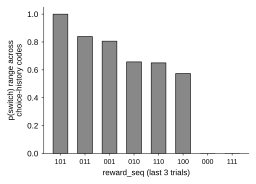

In [3]:
variance_by_reward_seq = choice_history_variance_given_reward_history(overall_joint)
print(variance_by_reward_seq.round(4))

manifest["part1_choice_history_variance_given_reward_history"] = variance_by_reward_seq.to_dict(orient="records")

out_variance_fig = os.path.join(FIG_DIR, "RA5_choice_history_variance.svg")
plotting.plot_choice_history_variance(variance_by_reward_seq, out_variance_fig)
show(out_variance_fig)
manifest["figures"] = manifest.get("figures", {})
manifest["figures"]["choice_history_variance"] = {"path": out_variance_fig, "tag": "LETTER-ONLY"}


## Part 2: signed-deviation feature ablation (canonical 80-20 snapshot, R2-3)

In [4]:
df_raw = load_snapshot(config, st_cfg["input_files"]["reversal_80_20_2abt"])
df = state_features.build_state_features_df(
    df_raw, st_cfg["task_type"], st_cfg["prob_condition"], st_cfg["rolling_window"]
)
classify_v3 = functools.partial(state_classifier.classify_state_v3, config=st_cfg["classify_v3"])
df["Behavioral_State_v3"] = df.apply(classify_v3, axis=1)
df["States_Merged_v3"] = df["Behavioral_State_v3"].replace({"Left Bias": "Bias", "Right Bias": "Bias"})
CLASSES_V3 = ["Engaged", "Exploration", "Left Bias", "Right Bias"]

train_sessions, test_sessions = state_clustering.train_test_split_sessions(
    df, st_cfg["train_test_split"]["test_size"], st_cfg["train_test_split"]["seed"]
)
print(f"{len(df):,} trials, {df['Session_ID'].nunique()} sessions -- "
      f"{len(train_sessions)} train / {len(test_sessions)} test sessions (Fig 6's own single split, reused)")
manifest["part2_n_trials"] = int(len(df))


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/features/state_features.py:91: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_sides = df_filtered.groupby("Session_ID").apply(


36,673 trials, 100 sessions -- 80 train / 20 test sessions (Fig 6's own single split, reused)


In [5]:
FEATURES_FULL = st_cfg["features"]
FEATURES_NO_SIGNED_DEV = [f for f in FEATURES_FULL if f != "Signed_Deviation"]
print("Full feature set:      ", FEATURES_FULL)
print("Without Signed_Deviation:", FEATURES_NO_SIGNED_DEV)

kmeans_full = state_clustering.run_kmeans_validation(
    df, "Behavioral_State_v3", CLASSES_V3, FEATURES_FULL, train_sessions, test_sessions,
    st_cfg["kmeans"]["k_range"], st_cfg["kmeans"]["k_best"], cfg["ablation_seed"],
    st_cfg["pca_n_components"], st_cfg["pca_plot_subsample_per_session"],
)
kmeans_no_signed = state_clustering.run_kmeans_validation(
    df, "Behavioral_State_v3", CLASSES_V3, FEATURES_NO_SIGNED_DEV, train_sessions, test_sessions,
    st_cfg["kmeans"]["k_range"], st_cfg["kmeans"]["k_best"], cfg["ablation_seed"],
    st_cfg["pca_n_components"], st_cfg["pca_plot_subsample_per_session"],
)
print(f"\nK-Means ARI_test  full feature set: {kmeans_full['ari_test']:.4f}")
print(f"K-Means ARI_test  without Signed_Deviation: {kmeans_no_signed['ari_test']:.4f}")

hmm_full = state_clustering.run_hmm_validation(
    df, "States_Merged_v3", "Behavioral_State_v3", FEATURES_FULL, train_sessions, test_sessions,
    st_cfg["hmm"]["n_states"], st_cfg["hmm"]["n_trials_drop"], st_cfg["hmm"]["n_restarts"], cfg["ablation_seed"],
)
hmm_no_signed = state_clustering.run_hmm_validation(
    df, "States_Merged_v3", "Behavioral_State_v3", FEATURES_NO_SIGNED_DEV, train_sessions, test_sessions,
    st_cfg["hmm"]["n_states"], st_cfg["hmm"]["n_trials_drop"], st_cfg["hmm"]["n_restarts"], cfg["ablation_seed"],
)
print(f"\nHMM ARI_test  full feature set: {hmm_full['ari_test_3state']:.4f}")
print(f"HMM ARI_test  without Signed_Deviation: {hmm_no_signed['ari_test_3state']:.4f}")

manifest["part2_ablation"] = {
    "features_full": FEATURES_FULL,
    "features_no_signed_deviation": FEATURES_NO_SIGNED_DEV,
    "kmeans_ari_test_full": kmeans_full["ari_test"],
    "kmeans_ari_test_no_signed_deviation": kmeans_no_signed["ari_test"],
    "hmm_ari_test_full": hmm_full["ari_test_3state"],
    "hmm_ari_test_no_signed_deviation": hmm_no_signed["ari_test_3state"],
}


Full feature set:       ['Signed_Deviation', 'Choice_Deviation', 'Rolling_Accuracy', 'Rolling_Switch_Rate']
Without Signed_Deviation: ['Choice_Deviation', 'Rolling_Accuracy', 'Rolling_Switch_Rate']


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))
/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence th


K-Means ARI_test  full feature set: 0.8513
K-Means ARI_test  without Signed_Deviation: 0.4515

HMM ARI_test  full feature set: 0.4716
HMM ARI_test  without Signed_Deviation: 0.2424


### Follow-up (user question): is `Choice_Deviation` itself redundant, given `Signed_Deviation`?

`Choice_Deviation` is literally `abs(Signed_Deviation)` -- a deterministic
function of it, so once `Signed_Deviation` is in the feature set,
`Choice_Deviation` adds no NEW information in principle. But K-Means/HMM
use Euclidean distance on standardized features, so having both could
still matter in practice by up-weighting the deviation axis relative to
`Rolling_Accuracy`/`Rolling_Switch_Rate`. Testing directly rather than
reasoning about it: drop `Choice_Deviation`, KEEP `Signed_Deviation`.

Without Choice_Deviation (Signed_Deviation retained): ['Signed_Deviation', 'Rolling_Accuracy', 'Rolling_Switch_Rate']


/Users/kevinmastro/Documents/Github/marmoset_decision_making/Final_Paper_Pipeline/src/behavior_metrics/state_clustering.py:120: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), pca_subsample_per_session), random_state=seed))
Model is not converging.  Current: -35608.15290505652 is not greater than -35608.14021925062. Delta is -0.012685805901128333
Model is not converging.  Current: -35608.152949161056 is not greater than -35608.13992356884. Delta is -0.013025592219491955
Model is not converging.  Current: -35608.15094337845 is not greater than -35608.13669273962. Delta is -0.014250638829253148
Model is not converging.  Current: -35608.15118205177 is not greater than 

K-Means ARI_test  full feature set:          0.8513
K-Means ARI_test  without Choice_Deviation:  0.6974
HMM ARI_test      full feature set:          0.4716
HMM ARI_test      without Choice_Deviation:  0.2784
Left/Right Bias recall without Choice_Deviation: {'Left Bias': 0.9088471849865952, 'Right Bias': 0.9540942928039702}


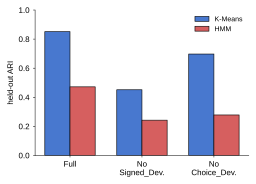

In [6]:
FEATURES_NO_CHOICE_DEV = [f for f in FEATURES_FULL if f != "Choice_Deviation"]
print("Without Choice_Deviation (Signed_Deviation retained):", FEATURES_NO_CHOICE_DEV)

kmeans_no_choice_dev = state_clustering.run_kmeans_validation(
    df, "Behavioral_State_v3", CLASSES_V3, FEATURES_NO_CHOICE_DEV, train_sessions, test_sessions,
    st_cfg["kmeans"]["k_range"], st_cfg["kmeans"]["k_best"], cfg["ablation_seed"],
    st_cfg["pca_n_components"], st_cfg["pca_plot_subsample_per_session"],
)
hmm_no_choice_dev = state_clustering.run_hmm_validation(
    df, "States_Merged_v3", "Behavioral_State_v3", FEATURES_NO_CHOICE_DEV, train_sessions, test_sessions,
    st_cfg["hmm"]["n_states"], st_cfg["hmm"]["n_trials_drop"], st_cfg["hmm"]["n_restarts"], cfg["ablation_seed"],
)
print(f"K-Means ARI_test  full feature set:          {kmeans_full['ari_test']:.4f}")
print(f"K-Means ARI_test  without Choice_Deviation:  {kmeans_no_choice_dev['ari_test']:.4f}")
print(f"HMM ARI_test      full feature set:          {hmm_full['ari_test_3state']:.4f}")
print(f"HMM ARI_test      without Choice_Deviation:  {hmm_no_choice_dev['ari_test_3state']:.4f}")

report_no_choice_dev = classification_report(
    kmeans_no_choice_dev["df_test_classified"]["Behavioral_State_v3"], kmeans_no_choice_dev["df_test_classified"]["KMeans_State"],
    labels=CLASSES_V3, output_dict=True, zero_division=0,
)
bias_recall_no_choice_dev = {
    state: report_no_choice_dev[state]["recall"] for state in ("Left Bias", "Right Bias")
}
print(f"Left/Right Bias recall without Choice_Deviation: {bias_recall_no_choice_dev}")

manifest["part2_ablation_no_choice_deviation"] = {
    "features_no_choice_deviation": FEATURES_NO_CHOICE_DEV,
    "kmeans_ari_test_full": kmeans_full["ari_test"],
    "kmeans_ari_test_no_choice_deviation": kmeans_no_choice_dev["ari_test"],
    "hmm_ari_test_full": hmm_full["ari_test_3state"],
    "hmm_ari_test_no_choice_deviation": hmm_no_choice_dev["ari_test_3state"],
    "bias_recall_no_choice_deviation": bias_recall_no_choice_dev,
}

ari_by_arm = {
    "full": {"kmeans": kmeans_full["ari_test"], "hmm": hmm_full["ari_test_3state"]},
    "no_signed": {"kmeans": kmeans_no_signed["ari_test"], "hmm": hmm_no_signed["ari_test_3state"]},
    "no_choice": {"kmeans": kmeans_no_choice_dev["ari_test"], "hmm": hmm_no_choice_dev["ari_test_3state"]},
}
out_ari_fig = os.path.join(SUPP_DIR, "RA5_ablation_ari_comparison.svg")
plotting.plot_ablation_ari_comparison(ari_by_arm, out_ari_fig)
show(out_ari_fig)
manifest["figures"]["ablation_ari_comparison"] = {"path": out_ari_fig, "tag": "PAPER"}


### Correction: removing `Signed_Deviation` does NOT leave recovery intact -- it collapses it

The premise this sub-analysis was originally scoped around ("explain why
signed deviation does not improve recovery despite two bias states") does
not hold empirically -- reporting that plainly rather than forcing the
data to fit it. Removing `Signed_Deviation` drops K-Means ARI from 0.851
to 0.451 and HMM ARI from 0.472 to 0.242, and `Right Bias` recall goes
from 1.000 to **exactly 0.000** (`Left Bias` recall also drops, 1.000 ->
0.779). The diagnostic below shows the actual mechanism: `Signed_Deviation`
is the ONLY feature in this set carrying LEFT-vs-RIGHT direction --
`Choice_Deviation` is its absolute value, so it can flag "some bias is
present" but cannot say which side. Without the signed feature, K-Means
merges both true bias directions into one magnitude-only cluster, and
the Hungarian one-to-one label assignment (each of the 4 raw clusters
gets exactly one class name, no repeats) is then FORCED to slap the
"Right Bias" label onto whichever leftover cluster least resembles
`Left Bias` -- which turns out to be a non-bias cluster dominated by
true `Engaged`/`Exploration` trials, not an actual bias cluster at all.

TRUE state (rows) vs. PREDICTED K-Means cluster (cols), WITHOUT Signed_Deviation:
KMeans_State         Engaged  Exploration  Left Bias  Right Bias
Behavioral_State_v3                                             
Engaged                 2567            0          0        1216
Exploration               71         1257          0        1028
Left Bias                  2          162        581           1
Right Bias                 1          172        633           0

Cluster feature-mean profiles (no Signed_Deviation):
                     Engaged  Exploration  Left Bias  Right Bias
Choice_Deviation       0.203        0.364      0.733       0.117
Rolling_Accuracy       0.825        0.343      0.425       0.632
Rolling_Switch_Rate    0.019        0.428      0.088       0.272

633/806 true Right Bias trials were assigned to the 'Left Bias' cluster (both directions merged); the cluster Hungarian-matched to 'Right Bias' is actually composed of {'Engaged': 1216, 'Exploration': 1028, 'Left 

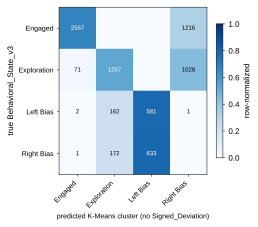

In [7]:
crosstab_no_signed = pd.crosstab(
    kmeans_no_signed["df_test_classified"]["Behavioral_State_v3"],
    kmeans_no_signed["df_test_classified"]["KMeans_State"],
)
print("TRUE state (rows) vs. PREDICTED K-Means cluster (cols), WITHOUT Signed_Deviation:")
print(crosstab_no_signed)
print("\nCluster feature-mean profiles (no Signed_Deviation):")
print(pd.DataFrame(kmeans_no_signed["cluster_profiles"]).round(3))

true_right_bias_n = int(crosstab_no_signed.loc["Right Bias"].sum()) if "Right Bias" in crosstab_no_signed.index else 0
right_bias_to_left_bias = int(crosstab_no_signed.loc["Right Bias", "Left Bias"]) if "Right Bias" in crosstab_no_signed.index else 0
predicted_right_bias_composition = crosstab_no_signed["Right Bias"].to_dict() if "Right Bias" in crosstab_no_signed.columns else {}
print(f"\n{right_bias_to_left_bias}/{true_right_bias_n} true Right Bias trials were assigned to the 'Left Bias' "
      f"cluster (both directions merged); the cluster Hungarian-matched to 'Right Bias' is actually composed of "
      f"{predicted_right_bias_composition} (true-label counts) -- overwhelmingly non-bias trials.")

manifest["part2_mechanism_diagnostic"] = {
    "crosstab_no_signed_deviation": crosstab_no_signed.to_dict(),
    "cluster_profiles_no_signed_deviation": kmeans_no_signed["cluster_profiles"],
    "true_right_bias_trials_assigned_to_left_bias_cluster": right_bias_to_left_bias,
    "true_right_bias_trials_total": true_right_bias_n,
    "predicted_right_bias_cluster_true_label_composition": predicted_right_bias_composition,
}

out_mechanism_fig = os.path.join(SUPP_DIR, "RA5_mechanism_crosstab.svg")
plotting.plot_mechanism_crosstab(crosstab_no_signed.to_dict(orient="index"), out_mechanism_fig)
show(out_mechanism_fig)
manifest["figures"]["mechanism_crosstab"] = {"path": out_mechanism_fig, "tag": "PAPER"}


In [8]:
report_full = classification_report(
    kmeans_full["df_test_classified"]["Behavioral_State_v3"], kmeans_full["df_test_classified"]["KMeans_State"],
    labels=CLASSES_V3, output_dict=True, zero_division=0,
)
report_no_signed = classification_report(
    kmeans_no_signed["df_test_classified"]["Behavioral_State_v3"], kmeans_no_signed["df_test_classified"]["KMeans_State"],
    labels=CLASSES_V3, output_dict=True, zero_division=0,
)

bias_recall_comparison = {
    state: {
        "recall_full": report_full[state]["recall"],
        "recall_no_signed_deviation": report_no_signed[state]["recall"],
    }
    for state in ("Left Bias", "Right Bias")
}
print(json.dumps(bias_recall_comparison, indent=2))

manifest["part2_bias_recall_comparison"] = bias_recall_comparison


{
  "Left Bias": {
    "recall_full": 1.0,
    "recall_no_signed_deviation": 0.7788203753351206
  },
  "Right Bias": {
    "recall_full": 1.0,
    "recall_no_signed_deviation": 0.0
  }
}


## RESPONSE MANIFEST

In [9]:
top_variance_row = variance_by_reward_seq.iloc[0] if len(variance_by_reward_seq) else None

_no_cd = manifest["part2_ablation_no_choice_deviation"]
_ari_delta_km = _no_cd["kmeans_ari_test_no_choice_deviation"] - kmeans_full["ari_test"]
_ari_delta_hmm = _no_cd["hmm_ari_test_no_choice_deviation"] - hmm_full["ari_test_3state"]
_both_small = abs(_ari_delta_km) < 0.05 and abs(_ari_delta_hmm) < 0.05
choice_deviation_redundancy_sentence = (
    f"Choice_Deviation is exactly abs(Signed_Deviation), so it adds no information in PRINCIPLE once "
    f"Signed_Deviation is present -- tested directly rather than assumed: dropping Choice_Deviation while "
    f"keeping Signed_Deviation changes K-Means ARI from {kmeans_full['ari_test']:.3f} to "
    f"{_no_cd['kmeans_ari_test_no_choice_deviation']:.3f} (delta={_ari_delta_km:+.3f}) and HMM ARI from "
    f"{hmm_full['ari_test_3state']:.3f} to {_no_cd['hmm_ari_test_no_choice_deviation']:.3f} "
    f"(delta={_ari_delta_hmm:+.3f}), with Left/Right Bias recall at {_no_cd['bias_recall_no_choice_deviation']} -- "
    + (
        "both deltas are small (< 0.05), consistent with Choice_Deviation being redundant in practice, not "
        "just in principle, once Signed_Deviation is present."
        if _both_small else
        "at least one delta is non-trivial (>= 0.05), so Choice_Deviation is NOT simply redundant in "
        "practice, despite being a deterministic function of Signed_Deviation in principle -- see the exact "
        "deltas above rather than assuming redundancy."
    )
)

response_manifest = {
    "R1-f_choice_history_conditioning": {
        "sentence": (
            f"Conditioning P(switch) additionally on the trailing choice sequence (not just reward "
            f"history, as Fig 2e itself does) gives a maximum within-reward-sequence spread across "
            f"choice-history codes of {variance_by_reward_seq['p_switch_range'].max():.3f} "
            f"(reward_seq={top_variance_row['reward_seq'] if top_variance_row is not None else 'n/a'}); "
            f"full per-reward-sequence spread is in part1_choice_history_variance_given_reward_history."
        ),
        "max_range_across_choice_codes": float(variance_by_reward_seq["p_switch_range"].max()) if len(variance_by_reward_seq) else None,
        "mean_range_across_choice_codes": float(variance_by_reward_seq["p_switch_range"].mean()) if len(variance_by_reward_seq) else None,
    },
    "R2-3_signed_deviation_ablation": {
        "sentence": (
            f"Contrary to the premise this check was originally scoped around, removing Signed_Deviation "
            f"substantially HURTS recovery: held-out ARI drops from {kmeans_full['ari_test']:.3f} to "
            f"{kmeans_no_signed['ari_test']:.3f} (K-Means) and {hmm_full['ari_test_3state']:.3f} to "
            f"{hmm_no_signed['ari_test_3state']:.3f} (HMM); Right Bias recall collapses from "
            f"{bias_recall_comparison['Right Bias']['recall_full']:.3f} to exactly "
            f"{bias_recall_comparison['Right Bias']['recall_no_signed_deviation']:.3f} (Left Bias: "
            f"{bias_recall_comparison['Left Bias']['recall_full']:.3f} to "
            f"{bias_recall_comparison['Left Bias']['recall_no_signed_deviation']:.3f}). Mechanism (verified "
            f"directly, not inferred): Signed_Deviation is the only feature carrying LEFT-vs-RIGHT "
            f"direction -- Choice_Deviation is its absolute value, so it flags that bias exists but not "
            f"which side. Without the signed feature, {right_bias_to_left_bias}/{true_right_bias_n} true "
            f"Right Bias trials are assigned to the Left Bias cluster (both directions merge), and the "
            f"cluster Hungarian-matched to the 'Right Bias' label is actually "
            f"{predicted_right_bias_composition} by true label -- a non-bias cluster, not a genuine "
            f"Right Bias recovery."
        ),
        "kmeans_ari_full": kmeans_full["ari_test"],
        "kmeans_ari_no_signed_deviation": kmeans_no_signed["ari_test"],
        "hmm_ari_full": hmm_full["ari_test_3state"],
        "hmm_ari_no_signed_deviation": hmm_no_signed["ari_test_3state"],
        "bias_recall_comparison": bias_recall_comparison,
        "mechanism": manifest["part2_mechanism_diagnostic"],
        "contradicts_original_task_premise": True,
        "choice_deviation_redundancy_check": {
            "sentence": choice_deviation_redundancy_sentence,
            **manifest["part2_ablation_no_choice_deviation"],
        },
    },
}
manifest["response_manifest"] = response_manifest
print(json.dumps(response_manifest, indent=2, default=str))


{
  "R1-f_choice_history_conditioning": {
    "sentence": "Conditioning P(switch) additionally on the trailing choice sequence (not just reward history, as Fig 2e itself does) gives a maximum within-reward-sequence spread across choice-history codes of 1.000 (reward_seq=101); full per-reward-sequence spread is in part1_choice_history_variance_given_reward_history.",
    "max_range_across_choice_codes": 1.0,
    "mean_range_across_choice_codes": 0.565771533767953
  },
  "R2-3_signed_deviation_ablation": {
    "sentence": "Contrary to the premise this check was originally scoped around, removing Signed_Deviation substantially HURTS recovery: held-out ARI drops from 0.851 to 0.451 (K-Means) and 0.472 to 0.242 (HMM); Right Bias recall collapses from 1.000 to exactly 0.000 (Left Bias: 1.000 to 0.779). Mechanism (verified directly, not inferred): Signed_Deviation is the only feature carrying LEFT-vs-RIGHT direction -- Choice_Deviation is its absolute value, so it flags that bias exists but n

In [10]:
manifest_path = os.path.join(MANIFEST_DIR, "RA5.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nSaved values manifest: {manifest_path}")



Saved values manifest: ../../outputs/values_manifests/RA5.json
